![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [6]:
# Convertir explicit a int ANTES de cualquier transformación
dataTraining['explicit'] = dataTraining['explicit'].astype(int)
dataTesting['explicit'] = dataTesting['explicit'].astype(int)

# Selección de variables
v_seleccionadas = ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
            'mode', 'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

X = dataTraining[v_seleccionadas]
y = dataTraining['popularity']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Ahora explicit cae en col_num automáticamente (es int)
col_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
col_cat = X_train.select_dtypes(include=['object']).columns.tolist()

# Solo dos pipelines, sin bool
num_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', num_trans, col_num),
        ('cat', cat_trans, col_cat)
    ])

X_train_prep = preprocesamiento.fit_transform(X_train)
X_val_prep = preprocesamiento.transform(X_val)
X_test_prep = preprocesamiento.transform(dataTesting[v_seleccionadas])

print(f"Dimensiones finales después de preprocesamiento:")
print(f"X_train_prep: {X_train_prep.shape}")
print(f"X_val_prep:   {X_val_prep.shape}")
print(f"X_test_prep:  {X_test_prep.shape}")

Dimensiones finales después de preprocesamiento:
X_train_prep: (63840, 128)
X_val_prep:   (15960, 128)
X_test_prep:  (34200, 128)


### PCA METODO FORWARD

In [12]:
# ✅ Convertir sparse a densa si es necesario
if hasattr(X_train_prep, 'toarray'):
    X_train_prep = X_train_prep.toarray()
    X_val_prep = X_val_prep.toarray()
    X_test_prep = X_test_prep.toarray()

# PCA SOBRE TRAIN
p = X_train_prep.shape[1]
pca = PCA(n_components=p)
pca.fit(X_train_prep)          # ✅ Hay que hacer fit antes de acceder a components_
A = pca.components_            # shape: (p, p)

# SELECCIÓN DE COMPONENTES Y ESTIMACIÓN
nComponentesElegidas = 7

ZTotalTrain = np.matmul(X_train_prep, A.T)  # ✅ Transponer A para proyectar correctamente
ZTrain = ZTotalTrain[:, :nComponentesElegidas]

regPCA = LinearRegression()
regPCA.fit(ZTrain, y_train)


#PREDICCIONES CON TEST

ZTotalTest = np.matmul(X_val_prep, A)#TRANSFORMAR VARIABLES
ZTest = ZTotalTest[:, :nComponentesElegidas]#USAR COMPONENTES ELEGIDAS

Ejecutando Selección Forward sobre Componentes Principales...
Paso 1: Agregado CP 30 | MSE Train: 487.27
Paso 2: Agregado CP 119 | MSE Train: 477.06
Paso 3: Agregado CP 38 | MSE Train: 470.48
Paso 4: Agregado CP 76 | MSE Train: 464.70
Paso 5: Agregado CP 9 | MSE Train: 459.87
Paso 6: Agregado CP 11 | MSE Train: 455.65
Paso 7: Agregado CP 94 | MSE Train: 451.63
Paso 8: Agregado CP 66 | MSE Train: 447.93
Paso 9: Agregado CP 110 | MSE Train: 445.09
Paso 10: Agregado CP 52 | MSE Train: 442.58
Paso 11: Agregado CP 125 | MSE Train: 440.15
Paso 12: Agregado CP 43 | MSE Train: 437.87
Paso 13: Agregado CP 20 | MSE Train: 435.74
Paso 14: Agregado CP 69 | MSE Train: 433.66
Paso 15: Agregado CP 44 | MSE Train: 431.60
Paso 16: Agregado CP 123 | MSE Train: 429.58
Paso 17: Agregado CP 84 | MSE Train: 427.57
Paso 18: Agregado CP 87 | MSE Train: 425.61
Paso 19: Agregado CP 39 | MSE Train: 423.68
Paso 20: Agregado CP 21 | MSE Train: 421.86
Paso 21: Agregado CP 77 | MSE Train: 420.09
Paso 22: Agregado CP

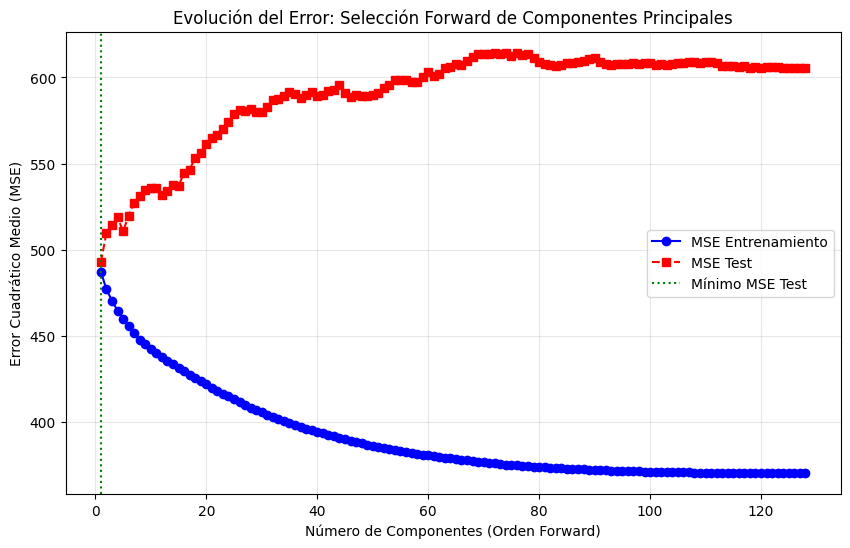


--- Resultados Finales ---
Orden óptimo de componentes: [30, 119, 38, 76, 9, 11, 94, 66, 110, 52, 125, 43, 20, 69, 44, 123, 84, 87, 39, 21, 77, 98, 49, 120, 37, 61, 8, 42, 114, 113, 122, 53, 62, 34, 118, 27, 19, 101, 121, 111, 100, 72, 0, 33, 47, 88, 54, 112, 102, 46, 56, 74, 28, 83, 93, 68, 75, 40, 57, 124, 107, 65, 64, 103, 115, 108, 10, 71, 51, 106, 24, 15, 73, 104, 45, 5, 60, 29, 117, 6, 80, 70, 7, 35, 36, 32, 97, 31, 116, 82, 92, 89, 109, 48, 2, 99, 4, 14, 16, 25, 55, 59, 1, 96, 85, 126, 26, 18, 67, 79, 50, 78, 13, 95, 17, 86, 41, 12, 105, 81, 23, 90, 63, 58, 22, 91, 3, 127]
MSE final en Test (con todos los componentes reordenados): 605.52
MSE mínimo en Test: 492.81 (con 1 componentes)


In [13]:
def forward_selection_pca_completo(Z_train, y_train, Z_test, y_test):
    n_componentes_totales = Z_train.shape[1]
    seleccionados = []
    restantes = list(range(n_componentes_totales))
    mse_train_historial = []
    mse_test_historial = []

    print("Ejecutando Selección Forward sobre Componentes Principales...")

    for i in range(n_componentes_totales):
        mejor_mse_paso = float('inf')
        mejor_componente_paso = None

        for componente in restantes:
            # Conjunto de componentes para probar
            combo_actual = seleccionados + [componente]

            # Ajuste del modelo
            modelo = LinearRegression()
            modelo.fit(Z_train[:, combo_actual], y_train)

            # Error en entrenamiento
            preds_train = modelo.predict(Z_train[:, combo_actual])
            mse_train = mean_squared_error(y_train, preds_train)

            if mse_train < mejor_mse_paso:
                mejor_mse_paso = mse_train
                mejor_componente_paso = componente

        # Actualizar listas con el mejor del paso
        seleccionados.append(mejor_componente_paso)
        restantes.remove(mejor_componente_paso)
        mse_train_historial.append(mejor_mse_paso)

        # Evaluar ese mismo modelo en Test para la visualización
        modelo_test = LinearRegression().fit(Z_train[:, seleccionados], y_train)
        preds_test = modelo_test.predict(Z_test[:, seleccionados])
        mse_test_paso = mean_squared_error(y_test, preds_test)
        mse_test_historial.append(mse_test_paso)

        print(f"Paso {i+1}: Agregado CP {mejor_componente_paso} | MSE Train: {mejor_mse_paso:.2f}")

    return seleccionados, mse_train_historial, mse_test_historial

# 1. Ejecutar el algoritmo
orden_optimo, historial_train, historial_test = forward_selection_pca_completo(ZTotalTrain, y_train, ZTotalTest, y_val)

# 2. Visualización del proceso
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(historial_train) + 1), historial_train, 'o-', label='MSE Entrenamiento', color='blue')
plt.plot(range(1, len(historial_test) + 1), historial_test, 's--', label='MSE Test', color='red')
plt.axvline(x=np.argmin(historial_test) + 1, color='green', linestyle=':', label='Mínimo MSE Test')
plt.xlabel('Número de Componentes (Orden Forward)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Evolución del Error: Selección Forward de Componentes Principales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Resultado Final
print(f"\n--- Resultados Finales ---")
print(f"Orden óptimo de componentes: {orden_optimo}")
print(f"MSE final en Test (con todos los componentes reordenados): {historial_test[-1]:.2f}")
print(f"MSE mínimo en Test: {min(historial_test):.2f} (con {np.argmin(historial_test) + 1} componentes)")

In [15]:
# Usando resultados ya calculados del Forward Selection

# 1. Número óptimo de componentes
n_optimo = np.argmin(historial_test) + 1
componentes_optimos = orden_optimo[:n_optimo]
print(f"Usando {n_optimo} componentes: {componentes_optimos}")

# 2. Proyectar test de competencia (ya tienes A y X_test_prep listos)
ZTotalTest_competencia = np.matmul(X_test_prep, A.T)

# 3. Reentrenar solo el modelo final (esto es rápido, no el forward selection)
modelo_final = LinearRegression()
modelo_final.fit(ZTotalTrain[:, componentes_optimos], y_train)

# 4. Predecir y guardar
y_pred = pd.DataFrame(
    modelo_final.predict(ZTotalTest_competencia[:, componentes_optimos]),
    index=dataTesting.index,
    columns=['Popularity']
)

y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

Usando 1 componentes: [30]


,Popularity
0,33.325229
1,34.996855
2,33.870283
3,33.677811
4,36.097325


In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
#np.random.seed(42)
#y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
#y_pred.to_csv('test_submission_file.csv', index_label='ID')
#y_pred.head()